In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow.keras import layers,Model

In [2]:

def VGG16_Scratch(input_shape=(32,32,3),num_classes=10):
  """
    Constructs a VGG-16 architecture from scratch.
    Includes Batch Normalization layers to solve vanishing gradients.
    """
  inputs = layers.Input(shape=input_shape)

  # Block-1
  x = layers.Conv2D(64,kernel_size=(3,3),padding='same',name='block1_conv1')(inputs)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)

  x = layers.Conv2D(64,kernel_size=(3,3),padding='same',name='block1_conv2')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)

  x = layers.MaxPooling2D(pool_size=(2,2),strides=(2,2),name = 'block1_pool')(x)

  # Block-2
  x = layers.Conv2D(128,kernel_size=(3,3),padding='same',name="block2_conv1")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)

  x = layers.Conv2D(128,kernel_size=(3,3),padding='same',name='block2_conv2')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)

  x = layers.MaxPooling2D(pool_size=(2,2),strides=(2,2),name = 'block2_pool')(x)

  # Block-3
  x = layers.Conv2D(256,kernel_size=(3,3),padding='same',name="block3_conv1")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)

  x = layers.Conv2D(256,kernel_size=(3,3),padding='same',name='block3_conv2')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)

  x = layers.Conv2D(256,kernel_size=(3,3),padding='same',name='block3_conv3')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)

  x = layers.MaxPooling2D(pool_size=(2,2),strides=(2,2),name='block3_pool')(x)

  # Block-4
  x = layers.Conv2D(512,kernel_size=(3,3),padding='same',name="block4_conv1")(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)

  x = layers.Conv2D(512,kernel_size=(3,3),padding='same',name='block4_conv2')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)

  x = layers.Conv2D(512,kernel_size=(3,3),padding='same',name='block4_conv3')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)

  x = layers.MaxPooling2D(pool_size=(2,2),strides=(2,2),name='block4_pool')(x)

  # Block-5
  x = layers.Flatten()(x)
  x = layers.Dense(512, name='fc1')(x)  # Reduced from 4096 to prevent overfitting on smaller images
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)
  x = layers.Dropout(0.5)(x)

  x = layers.Dense(512, name='fc2')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Activation('relu')(x)
  x = layers.Dropout(0.5)(x)

  outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

  return Model(inputs=inputs, outputs=outputs, name='vgg16_scratch_bn')

In [3]:
def load_and_preprocess_data():
    """Loads CIFAR-10 data and sets up data augmentation layers."""
    (x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

    # Normalize pixel values to be between 0 and 1
    x_train = x_train.astype("float32") / 255.0
    x_test = x_test.astype("float32") / 255.0

    # Convert labels to one-hot encoding vectors
    y_train = tf.keras.utils.to_categorical(y_train, 10)
    y_test = tf.keras.utils.to_categorical(y_test, 10)

    # On-the-fly augmentation layers to prevent overfitting
    data_augmentation = tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])

    return x_train, y_train, x_test, y_test, data_augmentation

In [4]:
def plot_results(history):
    """Generates accuracy and loss plots for the GitHub repository documentation."""
    plt.figure(figsize=(12, 4))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('VGG-16 Accuracy Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('VGG-16 Loss Curve')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.savefig('vgg16_learning_curves.png')
    print("Learning curves saved as 'vgg16_learning_curves.png'")


Loading CIFAR-10 Dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Building Model Layout...
Starting Model Training. Sit back, this might take a while...
Epoch 1/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 50s 91ms/step - accuracy: 0.4030 - loss: 1.6917 - val_accuracy: 0.4274 - val_loss: 1.5488 - learning_rate: 0.0010
Epoch 2/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.5706 - loss: 1.2206 - val_accuracy: 0.4991 - val_loss: 2.1170 - learning_rate: 0.0010
Epoch 3/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 92ms/step - accuracy: 0.6591 - loss: 0.9918 - val_accuracy: 0.6040 - val_loss: 1.1062 - learning_rate: 0.0010
Epoch 4/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 36s 91ms/step - accuracy: 0.7033 - loss: 0.8747 - val_accuracy: 0.7253 - val_loss: 0.8188 - learning_rate: 0.0010
Epoch 5/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 91ms/step - accuracy: 0.7307 - loss: 0.7901 - val_accuracy: 0.7351 - val_loss: 0.7975 - learning_rate: 0.0010
Epoch 6/40
391/391 ━━━━━━━━━━━━━━━━━━━━ 35s 91ms/step - accura

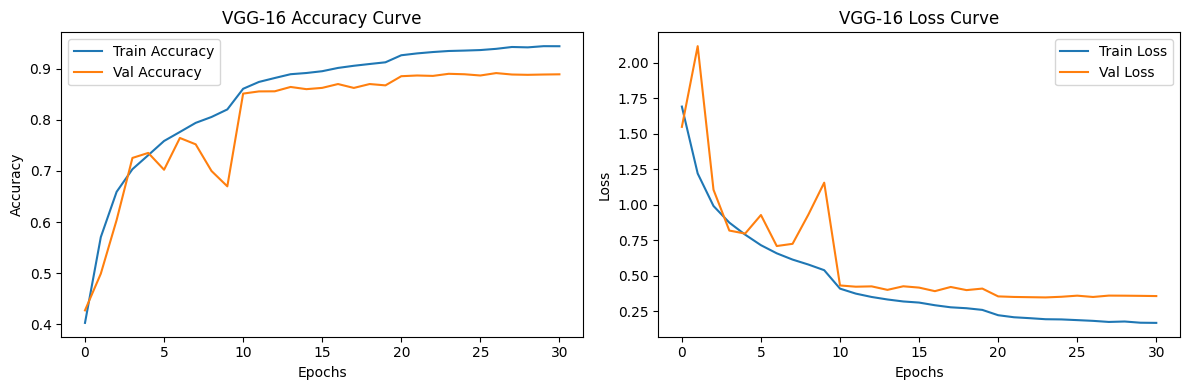

In [5]:
if __name__ == "__main__":
    # Hyperparameters
    BATCH_SIZE = 128
    EPOCHS = 40

    print("Loading CIFAR-10 Dataset...")
    x_train, y_train, x_test, y_test, augmentation = load_and_preprocess_data()

    print("Building Model Layout...")
    model = VGG16_Scratch(input_shape=(32, 32, 3), num_classes=10)

    # Wrap model with augmentation layers
    inputs = layers.Input(shape=(32, 32, 3))
    augmented_inputs = augmentation(inputs)
    outputs = model(augmented_inputs)
    final_model = Model(inputs=inputs, outputs=outputs)

    # Compile
    final_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Production Callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    ]

    print("Starting Model Training. Sit back, this might take a while...")
    history = final_model.fit(
        x_train, y_train,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        validation_data=(x_test, y_test),
        callbacks=callbacks
    )

    # Evaluate Performance
    test_loss, test_acc = final_model.evaluate(x_test, y_test, verbose=0)
    print(f"\nTraining Finished! Final Test Accuracy achieved: {test_acc*100:.2f}%")

    # Save the output visualization chart and trained weights
    plot_results(history)
    final_model.save('vgg16_scratch_cifar10.keras')
    print("Model saved to disk successfully as 'vgg16_scratch_cifar10.keras'")